### **1. Distribuzioni di probabilità**
Genera 1000 valori casuali da una distribuzione gamma con parametro di forma pari a 1.
Suggerimento: il parametro di forma viene passato come primo argomento quando si "congela" la distribuzione.

Traccia l’istogramma del campione e sovrapponi la PDF della distribuzione.

Stima il parametro di forma dal campione usando il metodo fit.

Extra:
Le distribuzioni hanno molti metodi utili. Esplorali usando il completamento automatico con il tasto TAB.

Traccia la funzione di distribuzione cumulativa (CDF).

Calcola la varianza.

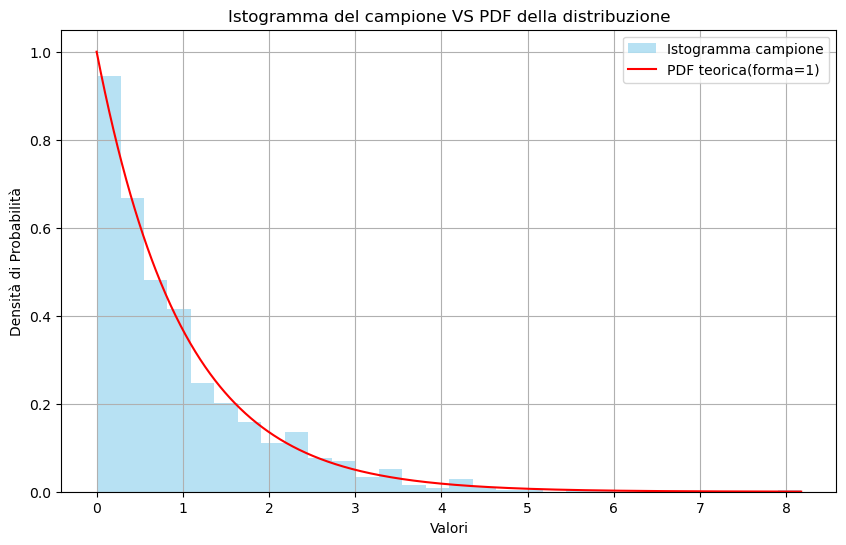

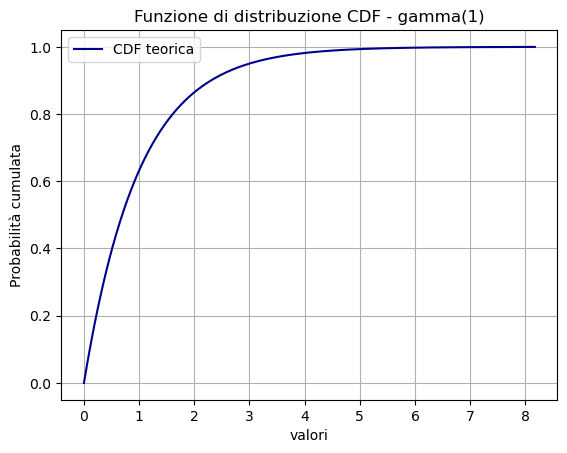

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import seaborn as sns

np.random.seed(42)
dist_gam = sp.stats.gamma(1)
campione = dist_gam.rvs(size=1000)

plt.figure(figsize=(10,6))
plt.hist(campione, bins=30, density=True, alpha=0.6, color="skyblue", label="Istogramma campione")
x = np.linspace(0, np.max(campione), 1000)
pdf_teorica = dist_gam.pdf(x)
plt.plot(x, pdf_teorica, color = "red", label = "PDF teorica(forma=1)")
plt.title("Istogramma del campione VS PDF della distribuzione")
plt.xlabel("Valori")
plt.ylabel("Densità di Probabilità")
plt.legend()
plt.grid(True)
plt.show()

forma_stimata, loc_stimata, scala_stimata = sp.stats.gamma.fit(campione)

cdf_teorica = dist_gam.cdf(x)
plt.plot(x,cdf_teorica, color="darkblue", label="CDF teorica")
plt.title("Funzione di distribuzione CDF - gamma(1)")
plt.xlabel("valori")
plt.ylabel("Probabilità cumulata")
plt.legend()
plt.grid(True)
plt.show()

### **2. Fitta i dati**
Prova a fittare i dati sottostanti con le migliori curve, calcola il MAE e l'RMSE
Esercizio 

Risultati temperature massime:
MAE: 2.5817932067932037, RMSE: 2.9601604601862292
Risultati temperature minime:
MAE: 7.5209790209790315, RMSE:8.533903317211054


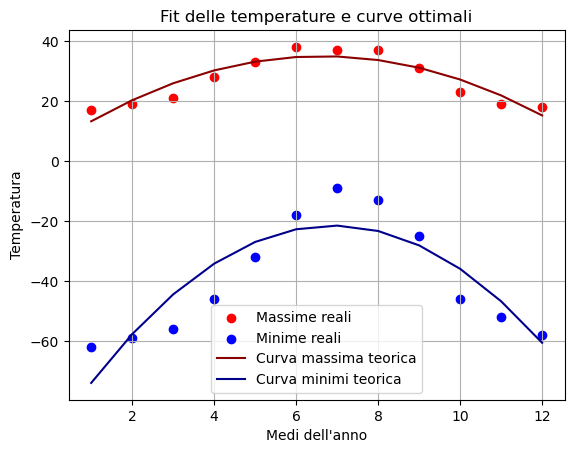

In [12]:
import numpy as np
import math
temp_max = np.array([17, 19, 21, 28, 33, 38, 37, 37, 31, 23, 19, 18])
temp_min = np.array([-62, -59, -56, -46, -32, -18, -9, -13, -25, -46, -52, -58])
import matplotlib.pyplot as plt
mesi = np.array([1,2,3,4,5,6,7,8,9,10,11,12])
coeff_max = np.polyfit(mesi,temp_max, deg=2)
coeff_min = np.polyfit(mesi, temp_min, deg=2)

formula_max = np.poly1d(coeff_max)
formula_min = np.poly1d(coeff_min)

#punti sulla curva teorica perfetta
curve_max = formula_max(mesi)
curve_min = formula_min(mesi)
#calcolo errore max e min per calcolarmi la mae e il rmse
errore_max = temp_max - curve_max
errore_min = temp_min - curve_min
#mae
mae_max = np.mean(np.abs(errore_max))
mae_min = np.mean(np.abs(errore_min))
#rmse
rmse_max = math.sqrt(np.mean(errore_max**2))
rmse_min = math.sqrt(np.mean(errore_min**2))
print("Risultati temperature massime:")
print(f"MAE: {mae_max}, RMSE: {rmse_max}")
print("Risultati temperature minime:")
print(f"MAE: {mae_min}, RMSE:{rmse_min}")

#RAPPRESENTAZIONE GRAFICA
plt.scatter(mesi, temp_max, color = "red", label="Massime reali")
plt.scatter(mesi, temp_min, color="blue", label="Minime reali")
plt.plot(mesi, curve_max, color="darkred", label="Curva massima teorica")
plt.plot(mesi, curve_min, color="darkblue", label="Curva minimi teorica")
plt.title("Fit delle temperature e curve ottimali")
plt.xlabel("Medi dell'anno")
plt.ylabel("Temperatura")
plt.legend()
plt.grid(True)
plt.show()
#osserviamo dal grafico che la curva delle minime è distante rispetto ai valori reali, questo lo indicano anche i valori di mae e rmse, (si discosta di circa 7 gradi)

### **3. Modello di regressione lineare dei seguenti dati**

 Calcola un modello di regressione lineare delle colonne mpg e disp del famoso dataset mtcars.

Dove: 

mpg = Miles Per Gallon → miglia per gallone, cioè una misura del consumo di carburante. Più alto è il valore, più efficiente è l’auto.

disp = Displacement → cilindrata del motore, in pollici cubici (cubic inches). Rappresenta il volume totale dei cilindri del motore. Più è alto, maggiore è la potenza potenziale del motore (ma anche il consumo).

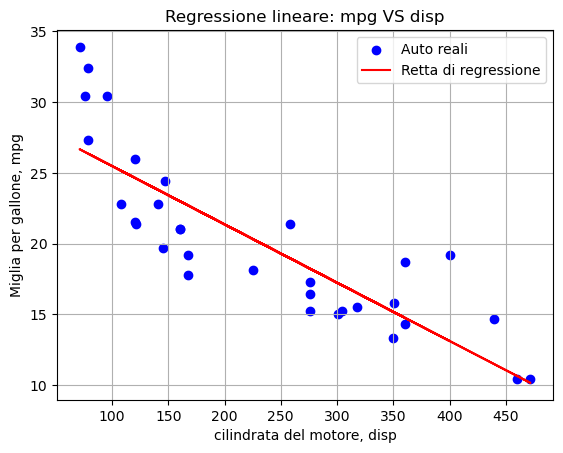

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math
# Load dataset from URL
df = pd.read_csv('https://gist.githubusercontent.com/seankross/a412dfbd88b3db70b74b/raw/5f23f993cd87c283ce766e7ac6b329ee7cc2e1d1/mtcars.csv')

# Display the dataframe
df
x = df["disp"].values
y = df["mpg"].values

coefficienti = np.polyfit(x,y,1)
pendenza = coefficienti[0]
intercetta = coefficienti[1]

plt.scatter(x,y, color="blue", label="Auto reali")
y_predetti = np.polyval(coefficienti, x)
plt.plot(x, y_predetti, color="red", label="Retta di regressione")
plt.title("Regressione lineare: mpg VS disp")
plt.legend()
plt.xlabel("cilindrata del motore, disp")
plt.ylabel("Miglia per gallone, mpg")
plt.grid(True)
plt.show()